# Tech Challenge - Fase 02  
## Classificação da Qualidade de Vinhos com Machine Learning

**Objetivo do projeto:** desenvolver uma pipeline de análise e modelagem capaz de prever se um vinho é de **Alta Qualidade** ou **Baixa/Média Qualidade** com base em suas características físico-químicas.

Este notebook mantem a ideia de:
- análise exploratória;
- criação de variável-alvo;
- validação estratificada;
- padronização dos dados;
- treinamento e comparação de modelos de classificação;
- uso do arquivo `WineQT.csv`;
- classificação binária conforme o enunciado:
  - **Alta Qualidade:** `quality >= 7`;
  - **Baixa/Média Qualidade:** `quality < 7`;
- organização da análise para atender às etapas exigidas: EDA, pré-processamento, modelos, avaliação e interpretação.

## 1. Como usar este notebook no Google Colab

1. Abra este arquivo `.ipynb` no Google Colab.
2. Faça upload do arquivo `WineQT.csv` na lateral esquerda do Colab ou deixe o arquivo na pasta `data/`.
3. Execute as células em sequência.

O código abaixo tenta localizar automaticamente o arquivo em alguns caminhos comuns:
- `/content/WineQT.csv`
- `/content/data/WineQT.csv`
- `data/WineQT.csv`
- `../data/WineQT.csv`

Caso não encontre, ele abre a opção de upload manual no Colab.

In [9]:
# Caso esteja no Google Colab e precise instalar/atualizar pacotes, descomente a linha abaixo.
# !pip -q install pandas numpy matplotlib scikit-learn joblib

## 2. Imports e configurações iniciais

In [10]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

RANDOM_STATE = 42

# Criação das pastas de saída, úteis para o padrão do repositório.
Path("results").mkdir(exist_ok=True)
Path("data").mkdir(exist_ok=True)

### 2.1 Padrão visual dos gráficos

Esta célula centraliza o estilo visual dos gráficos. As cores estão em código HEX para facilitar alterações futuras. Todos os gráficos usam títulos, eixos, rótulos e valores em negrito, além de linhas de fundo no padrão solicitado.

In [11]:
# ============================================================
# PADRÃO VISUAL DOS GRÁFICOS
# ============================================================

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# Cores em HEX — altere aqui caso queira trocar o padrão visual
# ------------------------------------------------------------
COR_PRINCIPAL = "#5A0F1B"      # Vinho escuro principal
COR_SECUNDARIA = "#9B1B30"     # Vinho médio
COR_CLARA = "#E8B4BC"          # Vinho claro
COR_GRID = "#D9D9D9"           # Cinza claro para linhas de fundo
COR_TEXTO = "#000000"          # Preto para texto
COR_FUNDO = "#FFFFFF"          # Branco para fundo

# Gradiente utilizado nos gráficos
CMAP_VERDE = LinearSegmentedColormap.from_list(
    "gradiente_verde",
    [COR_CLARA, COR_SECUNDARIA, COR_PRINCIPAL]
)

# Configuração global do Matplotlib
plt.rcParams.update({
    "figure.facecolor": COR_FUNDO,
    "axes.facecolor": COR_FUNDO,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "font.weight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.edgecolor": COR_TEXTO,
    "axes.labelcolor": COR_TEXTO,
    "xtick.color": COR_TEXTO,
    "ytick.color": COR_TEXTO,
    "legend.fontsize": 10,
    "legend.frameon": True,
})


def gerar_cores_gradiente(qtd, cor_inicio=COR_PRINCIPAL, cor_fim=COR_CLARA):
    """
    Gera uma lista de cores em gradiente.
    Mantém o padrão verde do gráfico de referência.
    """
    cmap = LinearSegmentedColormap.from_list("gradiente_custom", [cor_inicio, cor_fim])
    return [cmap(i / max(qtd - 1, 1)) for i in range(qtd)]


def formatar_grafico(
    ax,
    titulo=None,
    xlabel=None,
    ylabel=None,
    grid_axis="y",
    usar_grid=True
):
    """
    Aplica o padrão visual:
    - título em negrito;
    - eixos em negrito;
    - números dos eixos em negrito;
    - grid/linhas de fundo;
    - elementos principais na cor definida em HEX.
    """
    if titulo:
        ax.set_title(titulo, fontweight="bold", color=COR_TEXTO, pad=12)

    if xlabel:
        ax.set_xlabel(xlabel, fontweight="bold", color=COR_TEXTO)

    if ylabel:
        ax.set_ylabel(ylabel, fontweight="bold", color=COR_TEXTO)

    ax.set_axisbelow(True)

    if usar_grid:
        ax.grid(
            True,
            axis=grid_axis,
            linestyle="-",
            linewidth=0.8,
            alpha=0.65,
            color=COR_GRID
        )

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
        label.set_color(COR_TEXTO)

    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
        label.set_color(COR_TEXTO)

    for spine in ax.spines.values():
        spine.set_color(COR_TEXTO)
        spine.set_linewidth(0.8)

    return ax


def adicionar_rotulos_barras(
    ax,
    orientacao="vertical",
    prefixo="",
    sufixo="",
    casas_decimais=0
):
    """
    Adiciona valores nas barras em negrito.
    Funciona para gráficos de barras verticais e horizontais.
    """
    for barra in ax.patches:
        if orientacao == "horizontal":
            valor = barra.get_width()
            x = valor
            y = barra.get_y() + barra.get_height() / 2
            texto = f"{prefixo}{valor:,.{casas_decimais}f}{sufixo}"

            ax.annotate(
                texto,
                xy=(x, y),
                xytext=(6, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=COR_TEXTO
            )

        else:
            valor = barra.get_height()
            x = barra.get_x() + barra.get_width() / 2
            y = valor
            texto = f"{prefixo}{valor:,.{casas_decimais}f}{sufixo}"

            ax.annotate(
                texto,
                xy=(x, y),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color=COR_TEXTO
            )


## 3. Carregamento da base `WineQT.csv`

A base possui variáveis físico-químicas do vinho, como acidez, teor alcoólico, densidade, sulfatos e dióxido de enxofre, além da variável `quality`, que representa a nota atribuída ao vinho.

In [12]:
def localizar_arquivo_csv():
    caminhos_possiveis = [
        Path("/content/WineQT.csv"),
        Path("/content/data/WineQT.csv"),
        Path("WineQT.csv"),
        Path("data/WineQT.csv"),
        Path("../data/WineQT.csv"),
        Path("/mnt/data/WineQT.csv")  # útil apenas quando executado neste ambiente
    ]

    for caminho in caminhos_possiveis:
        if caminho.exists():
            return caminho

    # Fallback para Google Colab: upload manual
    try:
        from google.colab import files
        print("Arquivo WineQT.csv não encontrado. Faça o upload do CSV agora.")
        uploaded = files.upload()
        if uploaded:
            nome_arquivo = list(uploaded.keys())[0]
            return Path(nome_arquivo)
    except Exception:
        pass

    raise FileNotFoundError(
        "Não encontrei o WineQT.csv. Coloque o arquivo na pasta data/ ou faça upload no Colab."
    )

DATA_PATH = localizar_arquivo_csv()
print(f"Arquivo utilizado: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Dimensão da base:", df.shape)
df.head()

Arquivo utilizado: WineQT.csv
Dimensão da base: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 4. Compreensão do problema e criação da variável alvo

A variável original `quality` é uma nota numérica. Para o desafio, ela será transformada em uma classificação binária:

- `1` = Alta Qualidade, quando `quality >= 7`;
- `0` = Baixa/Média Qualidade, quando `quality < 7`.

Essa transformação converte o problema em uma tarefa de **classificação supervisionada binária**.

In [13]:
df["quality_class"] = (df["quality"] >= 7).astype(int)
df["quality_label"] = np.where(
    df["quality_class"] == 1,
    "Alta Qualidade",
    "Baixa/Média Qualidade"
)

df[["quality", "quality_class", "quality_label"]].head(10)

,quality,quality_class,quality_label
0,5,0,Baixa/Média Qualidade
1,5,0,Baixa/Média Qualidade
2,5,0,Baixa/Média Qualidade
3,6,0,Baixa/Média Qualidade
4,5,0,Baixa/Média Qualidade
5,5,0,Baixa/Média Qualidade
6,5,0,Baixa/Média Qualidade
7,7,1,Alta Qualidade
8,7,1,Alta Qualidade
9,5,0,Baixa/Média Qualidade


## 5. Visão geral e qualidade dos dados

Nesta etapa são avaliados:
- tipos das variáveis;
- valores faltantes;
- registros duplicados;
- estatísticas descritivas.

In [14]:
print("Informações gerais:")
display(df.info())

print("\nTotal de valores faltantes por coluna:")
display(df.isna().sum())

print("\nTotal de registros duplicados:", df.duplicated().sum())

print("\nEstatísticas descritivas:")
display(df.describe().T)

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  quality_class         1143 non-null   int64  
 14  quality_label         1143 non-null   str    
dtypes: float64(1

None


Total de valores faltantes por coluna:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_class           0
quality_label           0
dtype: int64


Total de registros duplicados: 0

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


## 6. Análise Exploratória de Dados - EDA

### 6.1 Distribuição da nota original de qualidade

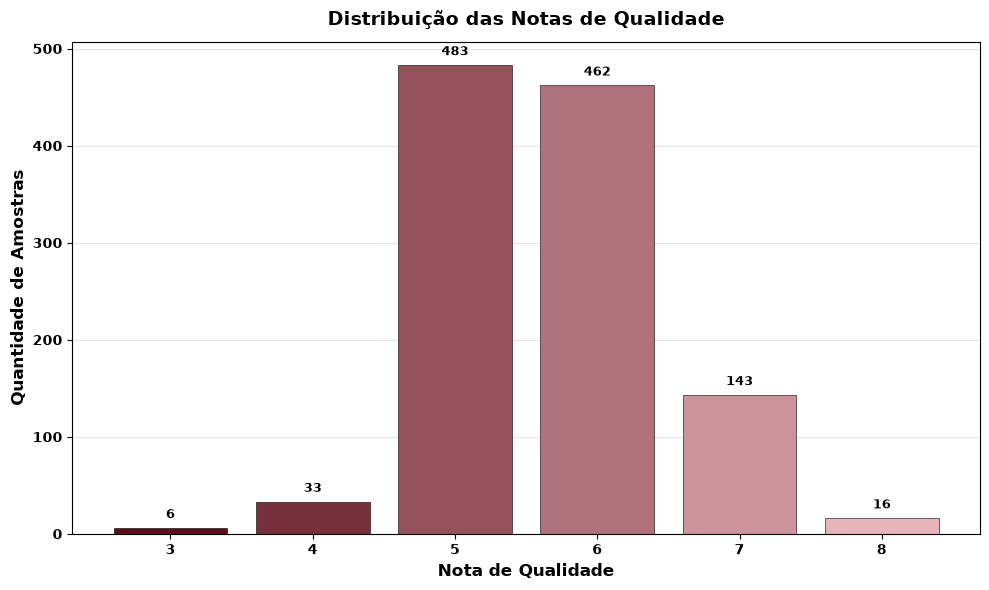

In [15]:
quality_counts = df["quality"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))

cores = gerar_cores_gradiente(len(quality_counts))

ax.bar(
    quality_counts.index.astype(str),
    quality_counts.values,
    color=cores,
    edgecolor=COR_TEXTO,
    linewidth=0.4
)

formatar_grafico(
    ax,
    titulo="Distribuição das Notas de Qualidade",
    xlabel="Nota de Qualidade",
    ylabel="Quantidade de Amostras",
    grid_axis="y"
)

adicionar_rotulos_barras(
    ax,
    orientacao="vertical",
    casas_decimais=0
)

plt.tight_layout()
plt.savefig("results/distribuicao_quality.png", dpi=160, bbox_inches="tight")
plt.show()


### 6.2 Balanceamento das classes

Este ponto é importante porque, em problemas de classificação, uma classe muito menor pode prejudicar o aprendizado do modelo. Neste caso, a classe de **Alta Qualidade** costuma representar uma parcela menor da base.

,quantidade,percentual
quality_label,,
Baixa/Média Qualidade,984,86.09
Alta Qualidade,159,13.91


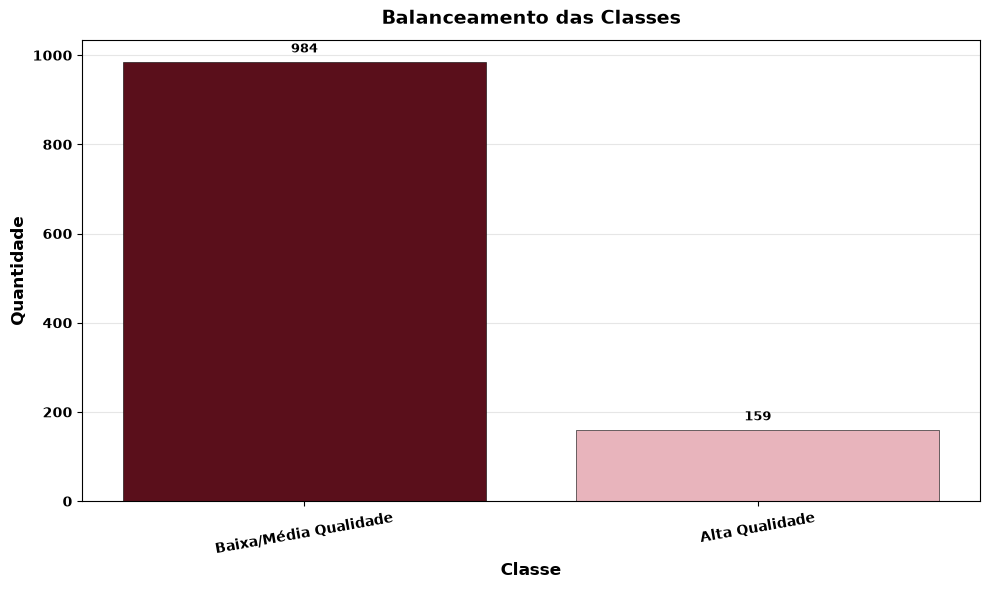

In [16]:
class_counts = (
    df["quality_label"]
    .value_counts()
    .reindex(["Baixa/Média Qualidade", "Alta Qualidade"])
)

class_percent = (class_counts / class_counts.sum() * 100).round(2)

balanceamento = pd.DataFrame({
    "quantidade": class_counts,
    "percentual": class_percent
})

display(balanceamento)

fig, ax = plt.subplots(figsize=(10, 6))

cores = gerar_cores_gradiente(len(class_counts))

ax.bar(
    class_counts.index,
    class_counts.values,
    color=cores,
    edgecolor=COR_TEXTO,
    linewidth=0.4
)

formatar_grafico(
    ax,
    titulo="Balanceamento das Classes",
    xlabel="Classe",
    ylabel="Quantidade",
    grid_axis="y"
)

adicionar_rotulos_barras(
    ax,
    orientacao="vertical",
    casas_decimais=0
)

for label in ax.get_xticklabels():
    label.set_rotation(10)
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("results/balanceamento_classes.png", dpi=160, bbox_inches="tight")
plt.show()


### 6.3 Correlações entre variáveis

A correlação ajuda a identificar relações lineares entre as variáveis. Ela não prova causalidade, mas orienta hipóteses sobre quais características podem estar mais associadas à qualidade do vinho.

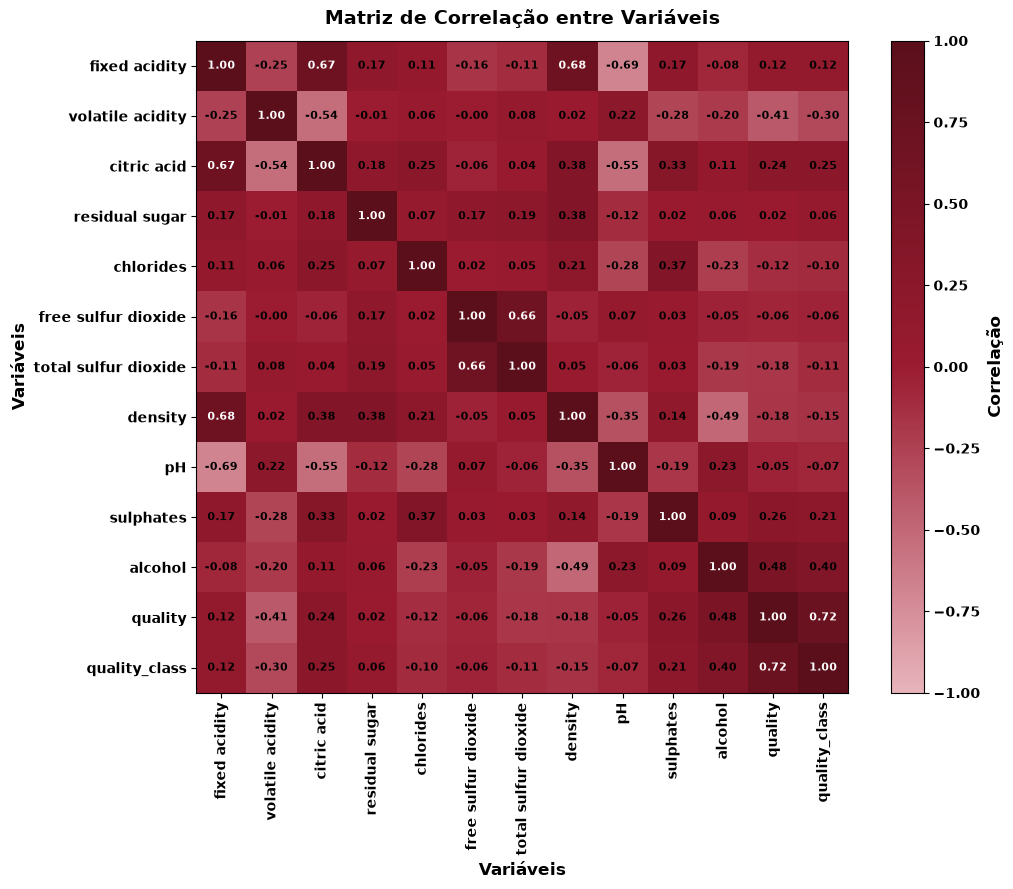

,correlacao_com_quality
quality_class,0.720433
alcohol,0.484866
volatile acidity,-0.407394
sulphates,0.257710
citric acid,0.240821
total sulfur dioxide,-0.183339
density,-0.175208
chlorides,-0.124085
fixed acidity,0.121970
free sulfur dioxide,-0.063260


In [17]:
# Removemos o Id da correlação porque ele é apenas um identificador.
corr_df = df.drop(columns=["Id", "quality_label"], errors="ignore").corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(
    corr_df.values,
    vmin=-1,
    vmax=1,
    cmap=CMAP_VERDE
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlação", fontweight="bold", color=COR_TEXTO)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_color(COR_TEXTO)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=90)
ax.set_yticklabels(corr_df.index)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        valor = corr_df.iloc[i, j]
        cor_texto = "#FFFFFF" if valor > 0.55 else COR_TEXTO
        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color=cor_texto
        )

formatar_grafico(
    ax,
    titulo="Matriz de Correlação entre Variáveis",
    xlabel="Variáveis",
    ylabel="Variáveis",
    usar_grid=False
)

plt.tight_layout()
plt.savefig("results/matriz_correlacao.png", dpi=160, bbox_inches="tight")
plt.show()

correlacao_quality = (
    corr_df["quality"]
    .drop("quality", errors="ignore")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(correlacao_quality.to_frame("correlacao_com_quality"))


### 6.4 Outliers pelo método IQR

O objetivo aqui não é remover automaticamente os outliers, mas identificar variáveis que possuem valores fora do padrão esperado. Em dados físico-químicos, outliers podem representar amostras reais, erros de medição ou características específicas de produção.

In [18]:
def detectar_outliers_iqr(dataframe, colunas):
    linhas = []

    for col in colunas:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        qtd_outliers = ((dataframe[col] < limite_inferior) | (dataframe[col] > limite_superior)).sum()

        linhas.append({
            "variavel": col,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "qtd_outliers": int(qtd_outliers),
            "perc_outliers": round(qtd_outliers / len(dataframe) * 100, 2)
        })

    return pd.DataFrame(linhas).sort_values("qtd_outliers", ascending=False)

colunas_numericas = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["Id", "quality_class"]
]

outliers = detectar_outliers_iqr(df, colunas_numericas)
display(outliers)

outliers.to_csv("results/outliers_iqr.csv", index=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,perc_outliers
3,residual sugar,0.850000,3.650000,110,9.62
4,chlorides,0.040000,0.120000,77,6.74
0,fixed acidity,4.100000,12.100000,44,3.85
9,sulphates,0.280000,1.000000,43,3.76
6,total sulfur dioxide,-39.000000,121.000000,40,3.50
7,density,0.992157,1.001257,36,3.15
11,quality,3.500000,7.500000,22,1.92
8,pH,2.912500,3.692500,20,1.75
5,free sulfur dioxide,-14.000000,42.000000,18,1.57
1,volatile acidity,0.021250,1.011250,14,1.22


### 6.5 Comparação de variáveis por classe

Os boxplots abaixo ajudam a comparar como algumas variáveis se comportam entre vinhos de baixa/média qualidade e vinhos de alta qualidade.

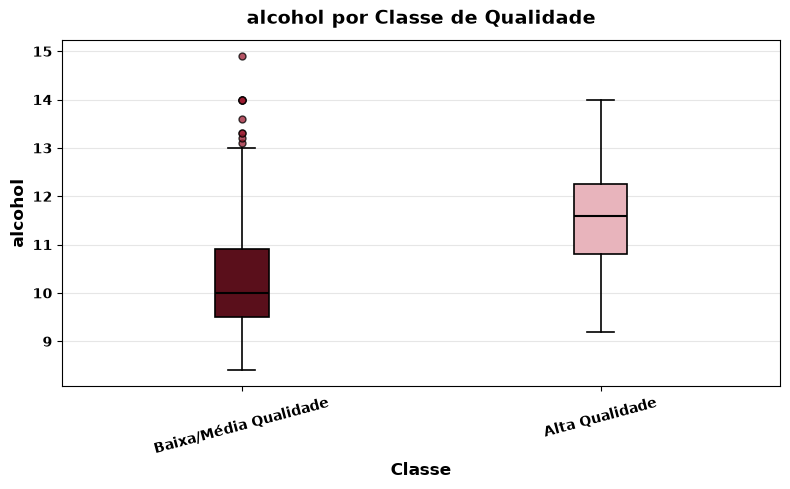

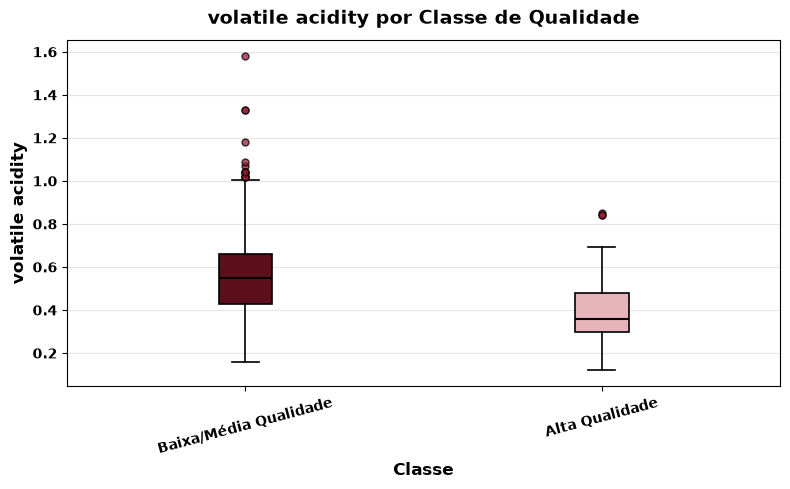

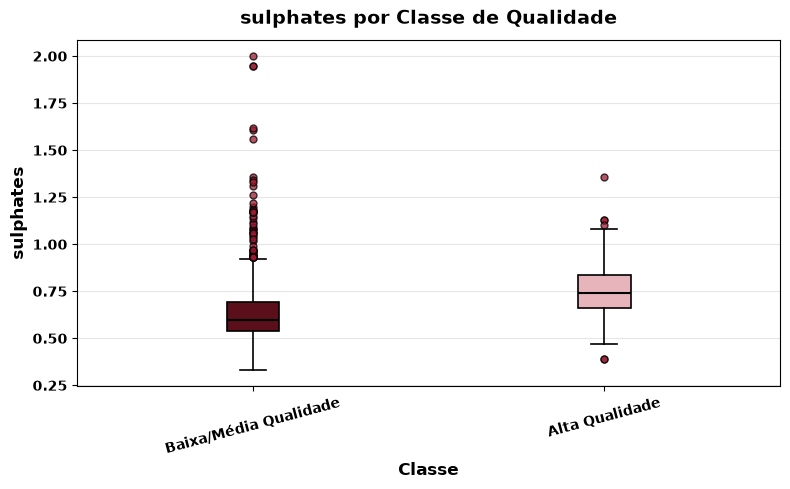

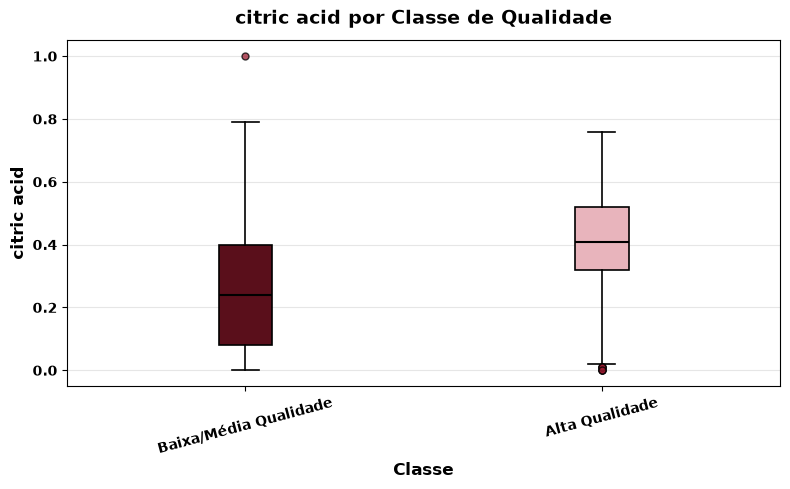

In [19]:
variaveis_para_boxplot = ["alcohol", "volatile acidity", "sulphates", "citric acid"]

for col in variaveis_para_boxplot:
    dados_plot = [
        df.loc[df["quality_class"] == 0, col].values,
        df.loc[df["quality_class"] == 1, col].values
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    box = ax.boxplot(
        dados_plot,
        tick_labels=["Baixa/Média Qualidade", "Alta Qualidade"],
        patch_artist=True,
        medianprops={"color": COR_TEXTO, "linewidth": 1.5},
        boxprops={"linewidth": 1.2, "color": COR_TEXTO},
        whiskerprops={"linewidth": 1.2, "color": COR_TEXTO},
        capprops={"linewidth": 1.2, "color": COR_TEXTO},
        flierprops={
            "marker": "o",
            "markerfacecolor": COR_SECUNDARIA,
            "markeredgecolor": COR_TEXTO,
            "markersize": 5,
            "alpha": 0.75
        }
    )

    cores = gerar_cores_gradiente(len(box["boxes"]))

    for patch, cor in zip(box["boxes"], cores):
        patch.set_facecolor(cor)

    formatar_grafico(
        ax,
        titulo=f"{col} por Classe de Qualidade",
        xlabel="Classe",
        ylabel=col,
        grid_axis="y"
    )

    for label in ax.get_xticklabels():
        label.set_rotation(15)
        label.set_fontweight("bold")

    plt.tight_layout()
    plt.savefig(f"results/boxplot_{col.replace(' ', '_')}_por_classe.png", dpi=160, bbox_inches="tight")
    plt.show()


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # renderiza sem abrir janela, bem mais rápido
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install seaborn

df = pd.read_csv('WineQT.csv').drop(columns=['Id'])
df['quality'] = df['quality'].astype(str)

g = sns.pairplot(
    df,
    hue='quality',
    diag_kind='hist',          # mais rápido que kde
    plot_kws={'alpha': 0.4, 's': 8},
    diag_kws={'bins': 20},
    palette='Reds',
)

g.figure.suptitle(
    'Gráfico de pares do conjunto de dados de vinhos por qualidade',
    y=1.01, fontsize=12
)



plt.savefig("results/wine_pairplot.png", dpi=160, bbox_inches="tight")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 7. Pré-processamento dos dados

Decisões adotadas:

1. `Id` será removido porque é apenas um identificador e não representa uma característica físico-química.
2. `quality` será removido das variáveis explicativas porque ela deu origem à variável alvo.
3. As classes serão separadas com `stratify=y` para preservar o balanceamento entre treino e teste.
4. Modelos sensíveis à escala, como Regressão Logística e SVM, usarão `StandardScaler`.

In [20]:
feature_cols = [
    col for col in df.columns
    if col not in ["Id", "quality", "quality_class", "quality_label"]
]

X = df[feature_cols]
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

print("\nDistribuição no treino:")
display(y_train.value_counts(normalize=True).rename("proporcao"))

print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True).rename("proporcao"))

Tamanho treino: (914, 11)
Tamanho teste: (229, 11)

Distribuição no treino:


quality_class
0    0.86105
1    0.13895
Name: proporcao, dtype: float64


Distribuição no teste:


quality_class
0    0.860262
1    0.139738
Name: proporcao, dtype: float64

## 8. Desenvolvimento dos modelos

Serão comparados modelos com características diferentes:

- **Baseline:** sempre prevê a classe majoritária. Serve como referência mínima.
- **Regressão Logística:** modelo simples, interpretável e bom como baseline estatístico.
- **Random Forest:** modelo baseado em árvores, capaz de capturar relações não lineares.
- **SVM:** modelo supervisionado que busca separar as classes com uma margem ótima.

O parâmetro `class_weight="balanced"` foi usado nos modelos compatíveis para compensar o desbalanceamento da classe de Alta Qualidade.

In [21]:
modelos = {
    "Baseline - Classe majoritária": DummyClassifier(strategy="most_frequent"),

    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=2,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])
}

## 9. Avaliação dos modelos

Por causa do desbalanceamento das classes, a **acurácia sozinha não é suficiente**. O foco principal será a capacidade do modelo identificar vinhos de **Alta Qualidade**, usando:

- `precision_alta`: entre os vinhos previstos como alta qualidade, quantos realmente eram;
- `recall_alta`: entre os vinhos realmente de alta qualidade, quantos o modelo encontrou;
- `f1_alta`: equilíbrio entre precisão e recall;
- `roc_auc`: capacidade geral de separação entre as classes.

In [22]:
resultados = []
relatorios = {}
matrizes_confusao = {}
modelos_treinados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None

    resultados.append({
        "modelo": nome,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_alta": precision_score(y_test, y_pred, zero_division=0),
        "recall_alta": recall_score(y_test, y_pred, zero_division=0),
        "f1_alta": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

    relatorios[nome] = classification_report(
        y_test,
        y_pred,
        target_names=["Baixa/Média", "Alta"],
        zero_division=0,
        digits=4
    )

    matrizes_confusao[nome] = confusion_matrix(y_test, y_pred)
    modelos_treinados[nome] = modelo

metricas_modelos = pd.DataFrame(resultados).sort_values("f1_alta", ascending=False)
display(metricas_modelos)

metricas_modelos.to_csv("results/metricas_modelos.csv", index=False)

for nome, relatorio in relatorios.items():
    print("=" * 80)
    print(nome)
    print(relatorio)

c:\Users\juliana.godoy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,modelo,accuracy,precision_alta,recall_alta,f1_alta,roc_auc
2,Random Forest,0.877729,0.550000,0.68750,0.611111,0.906409
3,SVM,0.816594,0.410714,0.71875,0.522727,0.869607
1,Regressão Logística,0.799127,0.379310,0.68750,0.488889,0.850412
0,Baseline - Classe majoritária,0.860262,0.000000,0.00000,0.000000,0.500000


Baseline - Classe majoritária
              precision    recall  f1-score   support

 Baixa/Média     0.8603    1.0000    0.9249       197
        Alta     0.0000    0.0000    0.0000        32

    accuracy                         0.8603       229
   macro avg     0.4301    0.5000    0.4624       229
weighted avg     0.7401    0.8603    0.7956       229

Regressão Logística
              precision    recall  f1-score   support

 Baixa/Média     0.9415    0.8173    0.8750       197
        Alta     0.3793    0.6875    0.4889        32

    accuracy                         0.7991       229
   macro avg     0.6604    0.7524    0.6819       229
weighted avg     0.8630    0.7991    0.8210       229

Random Forest
              precision    recall  f1-score   support

 Baixa/Média     0.9471    0.9086    0.9275       197
        Alta     0.5500    0.6875    0.6111        32

    accuracy                         0.8777       229
   macro avg     0.7485    0.7981    0.7693       229
weighted a

### 9.1 Matriz de confusão do melhor modelo

O melhor modelo será escolhido pelo maior `f1_alta`, pois o interesse é equilibrar acerto e cobertura da classe de Alta Qualidade.

Melhor modelo pelo F1 da classe Alta: Random Forest


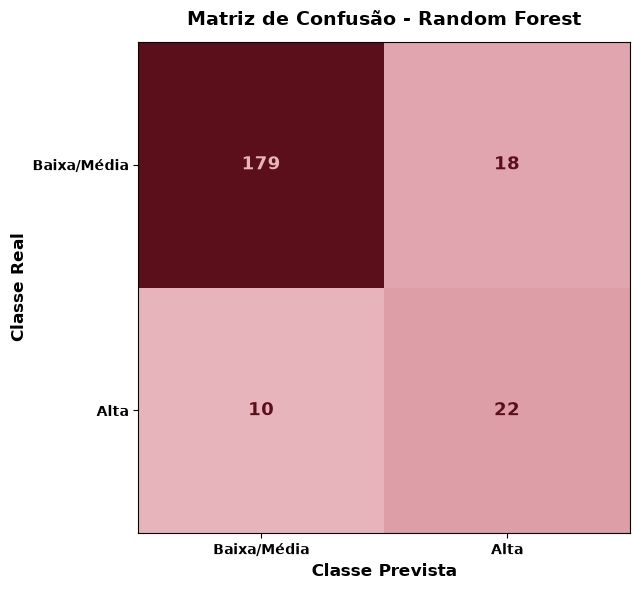

In [23]:
melhor_modelo_nome = metricas_modelos.iloc[0]["modelo"]
melhor_modelo = modelos_treinados[melhor_modelo_nome]

print("Melhor modelo pelo F1 da classe Alta:", melhor_modelo_nome)

y_pred_melhor = melhor_modelo.predict(X_test)

matriz_confusao_melhor = confusion_matrix(y_test, y_pred_melhor)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_melhor,
    display_labels=["Baixa/Média", "Alta"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap=CMAP_VERDE,
    colorbar=False,
    values_format="d"
)

formatar_grafico(
    ax,
    titulo=f"Matriz de Confusão - {melhor_modelo_nome}",
    xlabel="Classe Prevista",
    ylabel="Classe Real",
    usar_grid=False
)

# Deixa os números da matriz em negrito
for texto in disp.text_.ravel():
    texto.set_fontweight("bold")
    texto.set_fontsize(13)

plt.tight_layout()
plt.savefig("results/matriz_confusao_melhor_modelo.png", dpi=160, bbox_inches="tight")
plt.show()


### 9.2 Comparação visual dos modelos

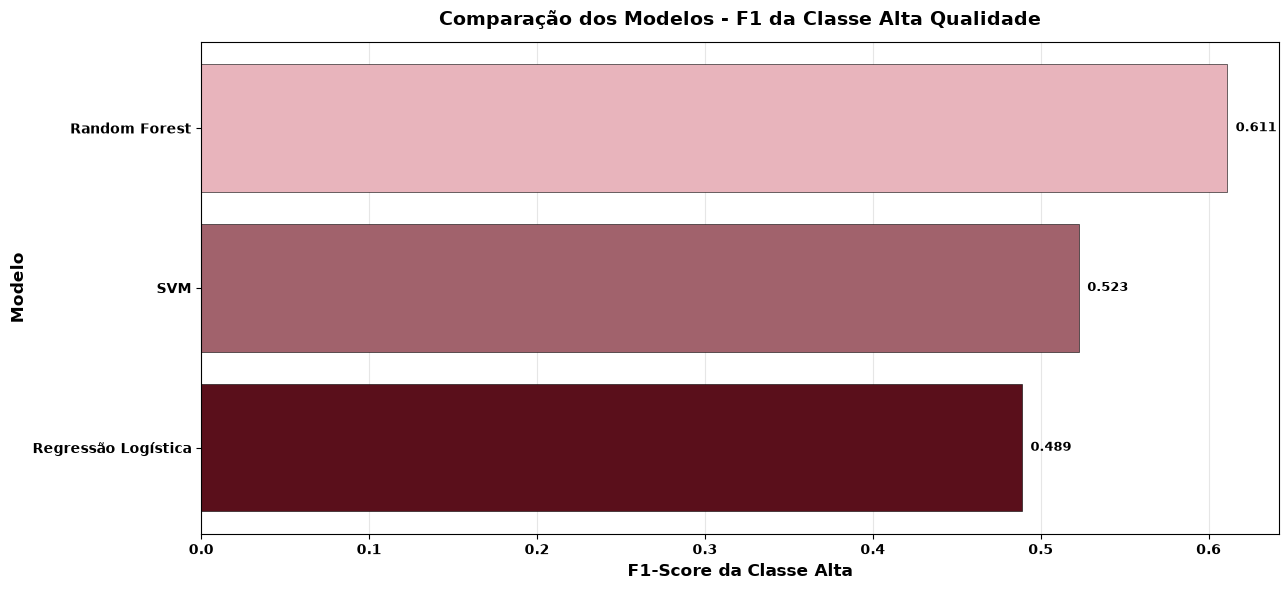

In [24]:
plot_df = metricas_modelos[
    metricas_modelos["modelo"] != "Baseline - Classe majoritária"
].sort_values("f1_alta")

fig, ax = plt.subplots(figsize=(13, 6))

cores = gerar_cores_gradiente(len(plot_df))

ax.barh(
    plot_df["modelo"],
    plot_df["f1_alta"],
    color=cores,
    edgecolor=COR_TEXTO,
    linewidth=0.4
)

formatar_grafico(
    ax,
    titulo="Comparação dos Modelos - F1 da Classe Alta Qualidade",
    xlabel="F1-Score da Classe Alta",
    ylabel="Modelo",
    grid_axis="x"
)

adicionar_rotulos_barras(
    ax,
    orientacao="horizontal",
    casas_decimais=3
)

plt.tight_layout()
plt.savefig("results/comparacao_modelos_f1.png", dpi=160, bbox_inches="tight")
plt.show()


## 10. Validação cruzada estratificada

A validação cruzada reduz a dependência de uma única divisão treino/teste e melhora a avaliação da estabilidade dos modelos.

In [25]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

linhas_cv = []

for nome, modelo in modelos.items():
    if "Baseline" in nome:
        continue

    scores = cross_validate(
        modelo,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    linha = {"modelo": nome}

    for metrica in scoring:
        linha[f"{metrica}_mean"] = scores[f"test_{metrica}"].mean()
        linha[f"{metrica}_std"] = scores[f"test_{metrica}"].std()

    linhas_cv.append(linha)

metricas_cv = pd.DataFrame(linhas_cv).sort_values("f1_mean", ascending=False)
display(metricas_cv)

metricas_cv.to_csv("results/metricas_validacao_cruzada.csv", index=False)

c:\Users\juliana.godoy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana.godoy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana.godoy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\juliana.godoy\AppData\Local\Programs\Python\Python31

,modelo,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
1,Random Forest,0.888018,0.037330,0.588429,0.113915,0.748790,0.075591,0.655843,0.094861,0.929640,0.034764
2,SVM,0.809278,0.020006,0.406820,0.032189,0.786492,0.028778,0.535398,0.028764,0.891405,0.030658
0,Regressão Logística,0.782154,0.022533,0.372979,0.028209,0.811694,0.032767,0.510099,0.025151,0.872794,0.029233


## 11. Interpretação das variáveis mais importantes

Para interpretação, será usado o modelo Random Forest, pois ele fornece importância das variáveis com facilidade. Essa análise ajuda a responder quais características físico-químicas parecem ter maior influência na classificação de qualidade.

,variavel,importancia
10,alcohol,0.236689
9,sulphates,0.146013
2,citric acid,0.139164
1,volatile acidity,0.108202
7,density,0.070754
6,total sulfur dioxide,0.060536
0,fixed acidity,0.060224
8,pH,0.050038
4,chlorides,0.047265
3,residual sugar,0.042693


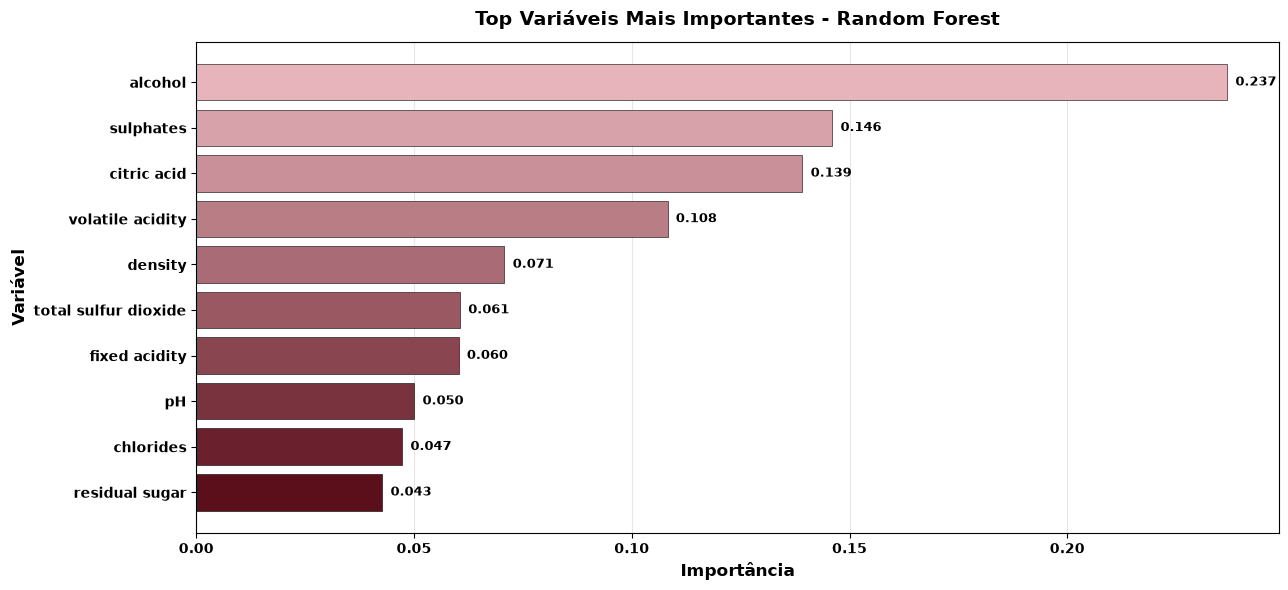

In [26]:
rf_model = modelos_treinados["Random Forest"]

importancia_variaveis = (
    pd.DataFrame({
        "variavel": feature_cols,
        "importancia": rf_model.feature_importances_
    })
    .sort_values("importancia", ascending=False)
)

display(importancia_variaveis)

importancia_variaveis.to_csv("results/importancia_variaveis_random_forest.csv", index=False)

top_importancias = importancia_variaveis.head(10).sort_values("importancia")

fig, ax = plt.subplots(figsize=(13, 6))

cores = gerar_cores_gradiente(len(top_importancias))

ax.barh(
    top_importancias["variavel"],
    top_importancias["importancia"],
    color=cores,
    edgecolor=COR_TEXTO,
    linewidth=0.4
)

formatar_grafico(
    ax,
    titulo="Top Variáveis Mais Importantes - Random Forest",
    xlabel="Importância",
    ylabel="Variável",
    grid_axis="x"
)

adicionar_rotulos_barras(
    ax,
    orientacao="horizontal",
    casas_decimais=3
)

plt.tight_layout()
plt.savefig("results/importancia_variaveis.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Conclusões executivas

Preencha/ajuste este texto após executar o notebook e revisar os resultados gerados.

### Principais achados

1. A base apresenta desbalanceamento: a maior parte dos vinhos está na categoria **Baixa/Média Qualidade**, enquanto a classe de **Alta Qualidade** é menor.
2. A análise exploratória indica que variáveis como teor alcoólico, acidez volátil, sulfatos e ácido cítrico podem ter relação relevante com a percepção de qualidade.
3. A comparação entre modelos deve priorizar métricas como `recall`, `precision` e `f1-score` da classe **Alta Qualidade**, e não apenas acurácia.
4. O melhor modelo pode apoiar produtores e enólogos na identificação antecipada de vinhos com maior potencial de qualidade, permitindo ajustes no processo produtivo.

### Implicações para o negócio

- Se o modelo indicar baixa probabilidade de alta qualidade, a equipe de produção pode revisar parâmetros físico-químicos antes da etapa final.
- Variáveis mais influentes podem ser monitoradas com maior atenção no processo produtivo.
- O modelo não substitui a análise sensorial de especialistas, mas pode funcionar como ferramenta de apoio à decisão e padronização da qualidade.

## 13. Salvando artefatos do projeto

Esta célula salva:
- métricas dos modelos;
- métricas da validação cruzada;
- modelo final em formato `.joblib`;
- resumo do dataset.

In [27]:
resumo_dataset = pd.DataFrame([{
    "total_registros": len(df),
    "total_colunas": df.shape[1],
    "missing_total": int(df.isna().sum().sum()),
    "duplicados": int(df.duplicated().sum()),
    "alta_qualidade": int(df["quality_class"].sum()),
    "baixa_media_qualidade": int((df["quality_class"] == 0).sum()),
    "percentual_alta": round(float(df["quality_class"].mean() * 100), 2)
}])

resumo_dataset.to_csv("results/resumo_dataset.csv", index=False)

joblib.dump(melhor_modelo, "results/melhor_modelo.joblib")

print("Arquivos salvos na pasta results/")
display(resumo_dataset)

Arquivos salvos na pasta results/


,total_registros,total_colunas,missing_total,duplicados,alta_qualidade,baixa_media_qualidade,percentual_alta
0,1143,15,0,0,159,984,13.91
